In [1]:
import matched_filter as mf
import importlib
import confusion_noise
importlib.reload(confusion_noise)
from confusion_noise import get_threshold_and_conf_noise_for_powerlaw
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from waveform_simplified import tophat_fd_waveform, get_snrs_theoretical
import jax
import priors
from confusion_noise import get_threshold_and_conf_noise_for_powerlaw
import matplotlib.pyplot as plt
import numpyro
from numpyro import distributions as dist
from numpyro import infer
import jax


plt.rcParams.update({
    # LaTeX rendering
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'text.latex.preamble': r'\usepackage{amsmath}',
    'pgf.texsystem': 'pdflatex',
    
    # Figure
    'figure.facecolor': 'white',
    'figure.edgecolor': 'white',
    
    # Axes
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.5,
    'axes.labelsize': 20,
    'axes.titlesize': 24,
    
    # Ticks - inward pointing, on all sides
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    'xtick.top': True,
    'ytick.right': True,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    
    # Lines
    'lines.linewidth': 2,
    'lines.markersize': 8,
    
    # Legend
    'legend.frameon': False,
    'legend.fontsize': 11,
    
    # Grid off
    'axes.grid': False,
})

mu (sources per bin) 15.4320987654321
2.9768709038256366e-12


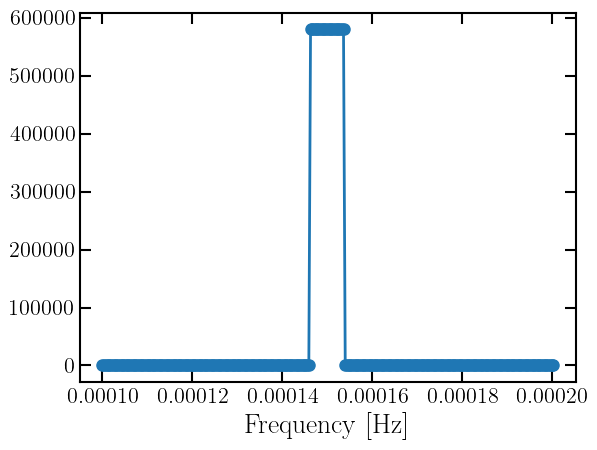

In [18]:
Tobs = 86400 * 30
flow = 1e-4
fhigh = 2e-4
df = 1 / Tobs 

# rho cutoff
rho_th = 5

# number of sources
N_sources = 200

# spectral index and low
# cutoff on amplitude distribution
alpha = 4
A_lower = 1e-3



# one sided PSD level of the noise
psd_level = 1.456

# width in frequency space
w = 20/Tobs

mu = N_sources * w / (fhigh - flow)
print('mu (sources per bin)', mu)
# corresponding "fdot" for a linear chirp
fdot = w / Tobs
print(fdot)

frequencies = np.arange(flow, fhigh + df, df)
Nbins = frequencies.size


# our waveforms will be just postive frequencies \tilde h(f). 
# so take 1-sided to 2-sided PSD, split variance between real and imaginary.
# that gives us a factor of 4.
fake_noise_fd = (np.random.randn(Nbins) + 1j * np.random.randn(Nbins)) * np.sqrt(psd_level * Tobs / 4)

plt.plot(frequencies, jnp.abs(tophat_fd_waveform(1, 1.5e-4, 0, fdot, frequencies)), '-o')
plt.xlabel("Frequency [Hz]")
plt.savefig("plots/example_waveform.pdf")
plt.show()

In [19]:
fcenters = np.random.rand(N_sources) * (fhigh - flow) + (flow)
Amplitudes = priors.sample_power_law_bounded(4, A_lower, 100, N_sources)
phi_centers = np.random.rand(N_sources) * 2 * jnp.pi

In [20]:
# jit
tophat_fd_waveform_jit = jax.jit(tophat_fd_waveform, static_argnames=('fdot'))

# leave fdot and frequencies constant, vmap over amplitudes, central frequency, and
# central phase
vmap_tophat_fd_waveform = jax.vmap(tophat_fd_waveform_jit, in_axes=[0, 0, 0, None, None])

In [21]:
fake_signals = jnp.sum(vmap_tophat_fd_waveform(Amplitudes, fcenters, phi_centers, fdot, jnp.array(frequencies)), axis=0)

In [22]:
# This is my data!
fake_data_total = fake_signals + fake_noise_fd

In [23]:
# first pass
Ath, Sconf, var_Sconf_ff = get_threshold_and_conf_noise_for_powerlaw(Tobs, fhigh - flow, psd_level, N_sources, alpha, rho_th, A_lower, 0, phase_variance=False, N_variance=False)
snrs = 2 * Amplitudes / np.sqrt(Sconf + psd_level) * jnp.sqrt(Tobs)

resolvable_sources_mask = snrs > rho_th

In [24]:
print(snrs[resolvable_sources_mask])

[5.6200624]


In [25]:
print(f"There are {np.sum(resolvable_sources_mask)} resolvable sources, probably")

# this will be our starting point.d
A_inj_resolvable = Amplitudes[resolvable_sources_mask]
fcenters_resolvable = fcenters[resolvable_sources_mask]
phi_centers_resolvable = phi_centers[resolvable_sources_mask]

There are 1 resolvable sources, probably


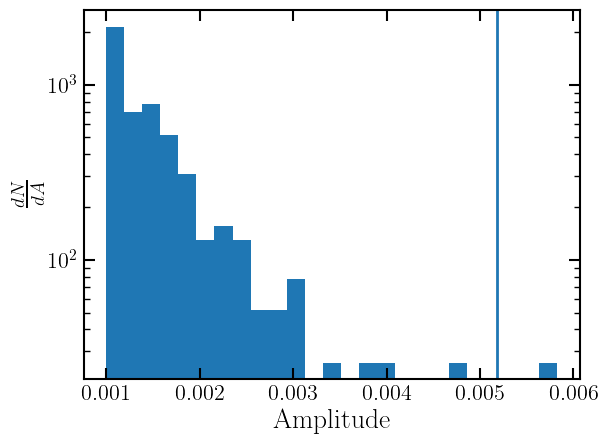

In [26]:
plt.hist(Amplitudes, density=True, bins='auto')
ax = plt.gca()
plt.xlabel("Amplitude")
plt.ylabel("$\\frac{dN}{dA}$")
ax.axvline(Ath)
plt.yscale("log")
plt.savefig("plots/amplitude_distribution.pdf")
plt.show()

In [27]:
Ath, Sconf, _ = get_threshold_and_conf_noise_for_powerlaw(
    Tobs, fhigh - flow, psd_level, N_sources, alpha, rho_th, A_lower, 0)
print(f"Ath: {Ath:.4f}")
print(f"Sconf: {Sconf:.4f}")
print(f"Sconf/psd_level: {Sconf/psd_level:.1f}")
n_resolvable = N_sources * (A_lower / Ath)**3
print(f"Expected resolvable: {n_resolvable:.1f}")

Ath: 0.0052
Sconf: 9.6847
Sconf/psd_level: 6.7
Expected resolvable: 1.4


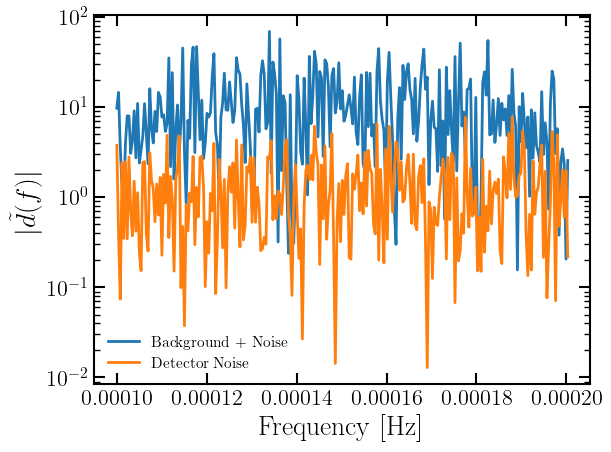

In [28]:
plt.plot(frequencies, 2 * jnp.abs(fake_signals + fake_noise_fd)**2 / Tobs, label='Background + Noise')
plt.plot(frequencies, 2 * jnp.abs(fake_noise_fd)**2 / Tobs, label='Detector Noise')
plt.xlabel("Frequency [Hz]")
plt.ylabel("$|\\tilde d(f)|$")
ax = plt.gca()

plt.yscale("log")
plt.legend()
plt.savefig("plots/simulatd_frequency_domain_data.pdf")
plt.show()

In [29]:
var_Sconf_ff

Array(0.5349447, dtype=float32, weak_type=True)

In [30]:
# from jax import hessian

# # Pick one resolved source
# idx = 0  # first injected source
# A_true = A_inj_resolvable[idx]
# f_true = fcenters_resolvable[idx]
# phi_true = phi_centers_resolvable[idx]

# def neg_log_likelihood(params):
#     A, fc, phi = params
#     h = tophat_fd_waveform(A, fc, phi, fdot, jnp.array(frequencies))
#     df = frequencies[1] - frequencies[0]
#     psd_total = psd_level  # or include sconf
#     return -4 * df * jnp.real(jnp.sum(jnp.conj(h) * fake_data_total / psd_total)) \
#            + 2 * df * jnp.real(jnp.sum(jnp.conj(h) * h / psd_total))

# fisher = hessian(neg_log_likelihood)(jnp.array([A_true, f_true, phi_true]))
# sigmas = jnp.sqrt(jnp.diag(jnp.linalg.inv(fisher)))
# print(f"sigma_A:   {sigmas[0]:.4e}")
# print(f"sigma_f:   {sigmas[1]:.4e}")
# print(f"sigma_phi: {sigmas[2]:.4f}")
# pseudo_sigma_f = 3 * sigmas[1]
# pseudo_sigma_phi = 3 * sigmas[2]

# sigma_A = sigmas[0]#  / jnp.abs(dAdu)
# # print(f"sigma_u: {sigma_u:.4e}")

In [31]:
def numpyro_model(data, max_num_resolvable=20, fdot=fdot,A_lower=A_lower,
                  frequencies=frequencies):

    # sample number of sources    
    log_10_N_sources = numpyro.sample("log_10_N_sources", dist.Uniform(1, 4))
    # psd
    log10_psd_val = jnp.log10(psd_level)# numpyro.sample('log10_psd', dist.Uniform(-1, 2))

    # Self-consistency: get threshold and confusion noise
    # alpha = numpyro.sample("alpha", dist.Uniform(2, 6))
    # alpha = numpyro.sample("alpha", dist.Delta(4.))
    alpha = numpyro.deterministic("alpha", 4.)
    # Now that those are sampled, get the strength of the background.
    Ath, Sconf_mean, var_Sconf_ff = get_threshold_and_conf_noise_for_powerlaw(
        Tobs, fhigh - flow, psd_level, 10**log_10_N_sources, alpha, rho_th, A_lower, 0,
        phase_variance=True, N_variance=False)

    # keep track of these in case we want them
    numpyro.deterministic("Ath", Ath)
    numpyro.deterministic("Sconf_mean", Sconf_mean)
    numpyro.deterministic("Sconf_var_an", 2 * var_Sconf_ff)


    # Confusion noise, incorporating its variance
    # Truncated normal seems right, given simulations.
    # sconf_sigma = numpyro.sample('sconf_sigma', dist.Uniform(0.1, jnp.sqrt(var_Sconf_ff) * 5))
    # var_Sconf_ff may still not be right yet. But it's working here...so...yay
    sconf = numpyro.sample("sconf", dist.TruncatedNormal(Sconf_mean, jnp.sqrt(2 * var_Sconf_ff), low=0.0))

    # Resolvable source parameters — amplitude truncated at Ath

    # Use Ath as the lower bound on the amplitudes
    # I think this should work for implementing our hard SNR cut. 
    # Instead of using a powerlaw, inverse CDF sample.
    
    # draw from a value in the CDF
    u_amp = numpyro.sample("u_amp", dist.Uniform(0, 1).expand([max_num_resolvable]))
    # transform from CDF to PDF of the prior
    Ath_1ma = Ath**(1 - alpha)
    hi_1ma = jnp.array(100.0)**(1 - alpha)
    amplitudes = numpyro.deterministic("amplitudes",
        (Ath_1ma + u_amp * (hi_1ma - Ath_1ma))**(1 / (1 - alpha)))


    # frequencies and phases
    freq_centers = numpyro.sample("freq_centers",
        dist.Uniform(flow, fhigh).expand([max_num_resolvable]))
    phi_centers = numpyro.sample("phi_centers",
        dist.Uniform(0, 2 * jnp.pi).expand([max_num_resolvable]))

    # Indicators
    z = numpyro.sample("z", dist.Bernoulli(0.5 * jnp.ones(max_num_resolvable)))

    # Poisson prior on number of active sources
    N_res = 10**log_10_N_sources * (A_lower / Ath)**(alpha - 1)
    numpyro.deterministic("Nres", N_res)
    numpyro.deterministic("Nk", jnp.sum(z))
    numpyro.factor("n_sources_prior", dist.Poisson(N_res).log_prob(jnp.sum(z)))

    # Likelihood
    ll = numpyro.deterministic("likelihood", mf.log_likelihood(
        amplitudes, freq_centers, phi_centers,
        fdot * jnp.ones(max_num_resolvable),
        z, data, 10**log10_psd_val + sconf, frequencies))
    numpyro.factor('ll', ll)

In [32]:
def numpyro_model_simple(data, max_num_resolvable=20, fdot=fdot, A_lower=A_lower,
                         frequencies=frequencies, beta=1.0):
    psd_total = jnp.array(psd_level)
    Ath_init, Sconf_init, _ = get_threshold_and_conf_noise_for_powerlaw(
        Tobs, fhigh - flow, psd_level, N_sources, alpha, rho_th, A_lower, 0)
    # print(f"Sconf: {Sconf_init:.2f}, psd_level: {psd_level:.2f}")

    # In the model:
    psd_total = jnp.array(psd_level + Sconf_init)
    log10_amplitudes = numpyro.sample("log10_amplitudes",
        dist.Uniform(np.log10(A_lower), 0).expand([max_num_resolvable]))
    freq_centers = numpyro.sample("freq_centers",
        dist.Uniform(flow, fhigh).expand([max_num_resolvable]))
    phi_centers = numpyro.sample("phi_centers",
        dist.Uniform(0, 2 * jnp.pi).expand([max_num_resolvable]))
    z = numpyro.sample("z", dist.Bernoulli(0.5 * jnp.ones(max_num_resolvable)))

    ll = mf.log_likelihood(
        10**(log10_amplitudes), freq_centers, phi_centers,
        fdot * jnp.ones(max_num_resolvable),
        z, data, psd_total, frequencies)
    numpyro.deterministic("likelihood", ll)
    numpyro.factor('ll', beta * ll)

In [33]:
from numpyro.infer.util import initialize_model
from numpyro.infer import init_to_value



max_num_resolvable = 5
n_true = int(np.sum(resolvable_sources_mask))
print(n_true)
# Pad true values into first n_true slots, fill remainder with draws from prior
Ath_init, Sconf_init, _ = get_threshold_and_conf_noise_for_powerlaw(
    Tobs, fhigh - flow, psd_level, N_sources, alpha, rho_th, A_lower, 0,
    phase_variance=True, N_variance=False)

init_amplitudes = jnp.concatenate([
    A_inj_resolvable,
    priors.sample_power_law_bounded(alpha, Ath_init, 10, max_num_resolvable - n_true)
])
init_freq_centers = jnp.concatenate([
    fcenters_resolvable,
    np.random.uniform(flow, fhigh, max_num_resolvable - n_true)
])
init_phi_centers = jnp.concatenate([
    phi_centers_resolvable,
    np.random.uniform(0, 2 * np.pi, max_num_resolvable - n_true)
])
init_z = jnp.concatenate([jnp.ones(n_true), jnp.zeros(max_num_resolvable - n_true)])

init_values = {
    "log_10_N_sources": jnp.log10(jnp.array(N_sources, dtype=float)),
    "alpha": jnp.array(3.99),
    "log10_psd": jnp.log10(jnp.array(psd_level, dtype=float)),
    "sconf_sigma": jnp.array(0.5),
    "log_sconf": jnp.log(Sconf_init),
    "amplitudes": init_amplitudes,
    "freq_centers": init_freq_centers,
    "phi_centers": init_phi_centers,
    "z": init_z,
}
kernel = infer.DiscreteHMCGibbs(
    infer.NUTS(numpyro_model, init_strategy=init_to_value(values=init_values), max_tree_depth=6, target_accept_prob=0.9),
    modified=True)
mcmc = infer.MCMC(kernel, num_warmup=20000, num_samples=10000, num_chains=1, chain_method=jax.vmap)
mcmc.run(jax.random.key(0), fake_data_total, max_num_resolvable=max_num_resolvable)

1


sample: 100%|██████████| 30000/30000 [01:21<00:00, 369.93it/s, 63 steps of size 1.97e-02. acc. prob=0.89]


In [34]:
samples = mcmc.get_samples()

In [35]:
mcmc.print_summary()


                        mean       std    median      5.0%     95.0%     n_eff     r_hat
   freq_centers[0]      0.00      0.00      0.00      0.00      0.00   1451.56      1.00
   freq_centers[1]      0.00      0.00      0.00      0.00      0.00   1144.40      1.01
   freq_centers[2]      0.00      0.00      0.00      0.00      0.00      4.67      1.51
   freq_centers[3]      0.00      0.00      0.00      0.00      0.00   1046.11      1.00
   freq_centers[4]      0.00      0.00      0.00      0.00      0.00      5.93      1.29
  log_10_N_sources      2.21      0.06      2.21      2.11      2.30     76.16      1.08
    phi_centers[0]      1.48      0.16      1.48      1.22      1.74   1157.64      1.00
    phi_centers[1]      4.21      0.18      4.21      3.91      4.51    781.32      1.00
    phi_centers[2]      3.19      0.78      3.13      1.58      4.44     22.32      1.01
    phi_centers[3]      2.39      0.20      2.39      2.09      2.73    738.13      1.01
    phi_centers[4]  

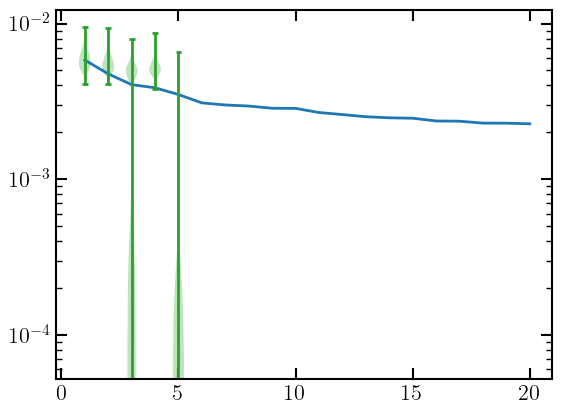

In [36]:
plt.plot(np.arange(1, 21), np.sort(Amplitudes)[::-1][:20])
plt.plot(np.arange(1, A_inj_resolvable.size + 1), np.sort(A_inj_resolvable)[::-1])
idxs = np.argsort(np.mean(samples['amplitudes'], axis=0))[::-1]
plt.violinplot(samples['amplitudes'] * samples['z'])
plt.yscale("log")
plt.show()


In [37]:
empirical_psd = 2 * jnp.mean(jnp.abs(fake_data_total)**2) / Tobs
print(f"Empirical PSD: {empirical_psd:.2f}")
print(f"psd_level: {psd_level:.2f}")
print(f"Empirical Sconf: {empirical_psd - psd_level:.2f}")
print(f"Analytic Sconf_mean: {samples['Sconf_mean'][0]:.2f}")

Empirical PSD: 11.95
psd_level: 1.46
Empirical Sconf: 10.49
Analytic Sconf_mean: 6.23


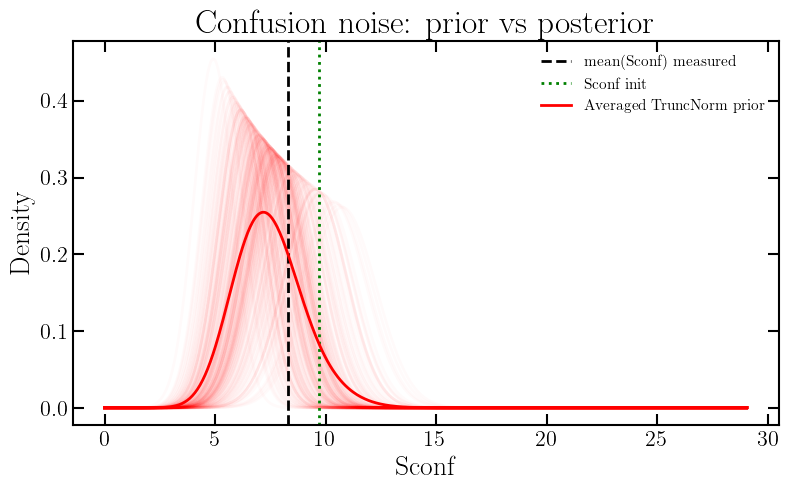

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))

# Histogram of sampled sconf
# ax.hist(samples['sconf'], bins=30, density=True, alpha=0.5, color='blue', label='Sampled sconf')

# Prior envelope: TruncatedNormal with sampled (Sconf_mean, sconf_sigma)
x = np.linspace(0, max(np.max(samples['sconf']) * 1.5, float(Sconf_init) * 3), 500)

from scipy.stats import truncnorm

pdf_sum = np.zeros_like(x)
n_plot = min(200, samples['Sconf_mean'].shape[0])
idxs = np.random.choice(samples['Sconf_mean'].shape[0], n_plot, replace=False)

for idx in idxs:
    mu_i = float(samples['Sconf_mean'][idx])
    sig_i = np.sqrt(float(samples['Sconf_var_an'][idx]))
    a_i = (0 - mu_i) / sig_i
    pdf_i = truncnorm.pdf(x, a_i, np.inf, loc=mu_i, scale=sig_i)
    pdf_sum += pdf_i
    ax.plot(x, pdf_i, 'r-', alpha=0.02)
ax.axvline(np.mean(samples['sconf']), label='mean(Sconf) measured', c='k', ls='--')
ax.axvline(Sconf_init, label='Sconf init', c='g', ls=':')
# Average
pdf_avg = pdf_sum / n_plot
ax.plot(x, pdf_avg, 'r-', lw=2, label='Averaged TruncNorm prior')

ax.set_xlabel("Sconf")
ax.set_ylabel("Density")
ax.legend()
ax.set_title("Confusion noise: prior vs posterior")
plt.tight_layout()
plt.savefig("plots/sconf_distribution.pdf")
plt.show()

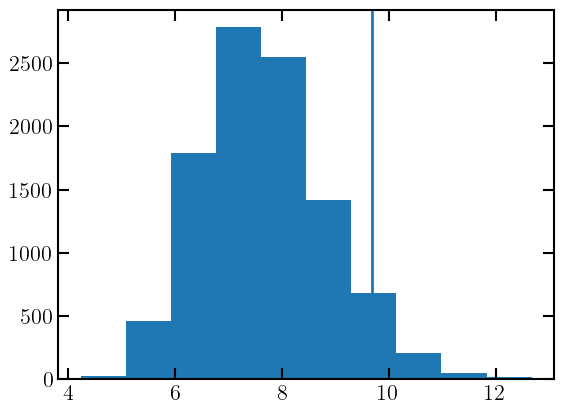

In [39]:
plt.hist(samples['Sconf_mean'])
ax = plt.gca()
ax.axvline(Sconf)
plt.show()

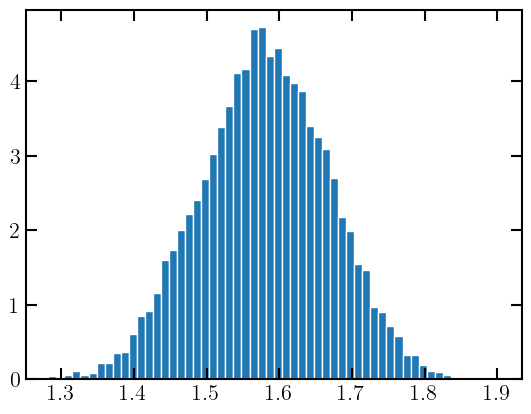

In [40]:
# can't use this for multiple chains where label switching is an issue.
# plt.hist(np.sum(samples['z'], axis=1), np.linspace(-0.5, 10.5, num=12), edgecolor='w', density=True)
# plt.show()

plt.hist(samples['Nres'], bins='auto', edgecolor='w', density=True)
plt.show()


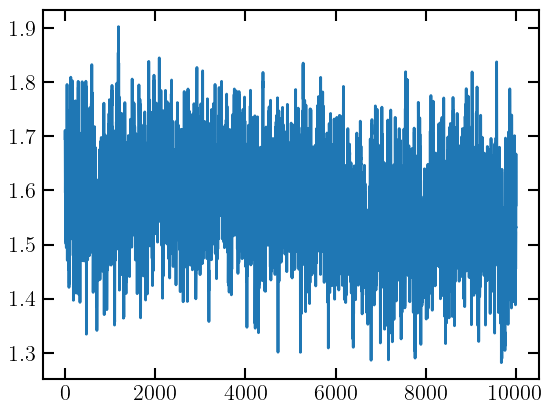

In [41]:
plt.plot(samples['Nres'])

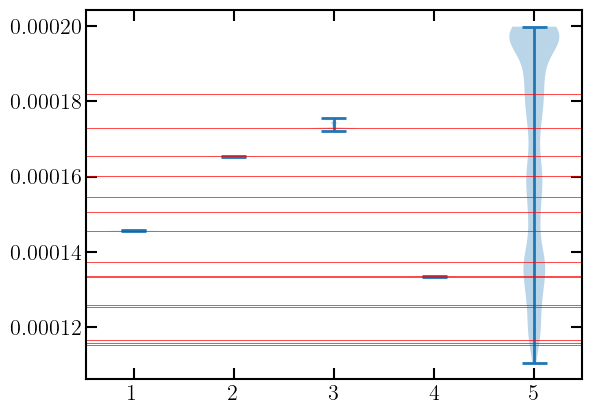

In [62]:
plt.violinplot(samples['freq_centers'])
ax = plt.gca()
ampl_idxs = np.argsort(Amplitudes)[::-1]
for a in fcenters[ampl_idxs][:15]:
    ax.axhline(a, lw=0.5, c='r')
# plt.yscale("log")
# for ifc in init_freq_centers:
#     ax.axhline(ifc, lw=0.5, c='g')

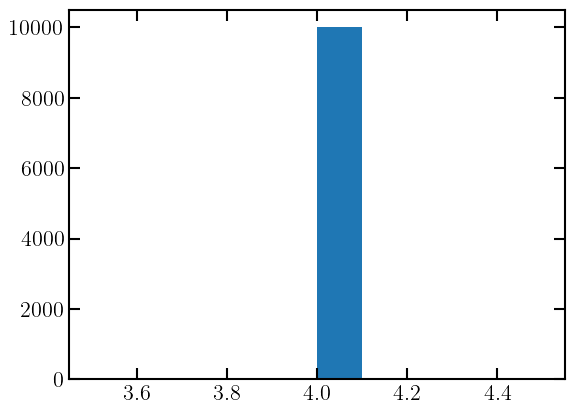

In [43]:
plt.hist(samples['alpha'])
plt.show()

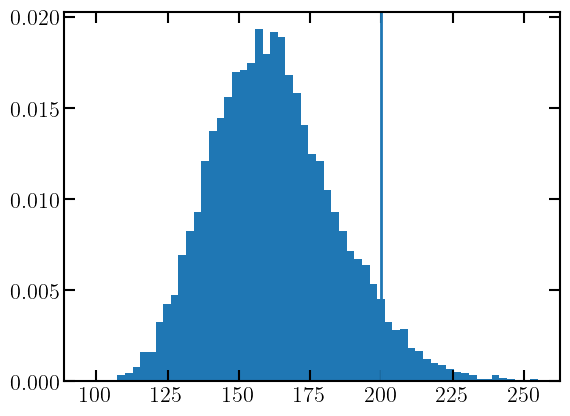

In [44]:
plt.hist(10**samples['log_10_N_sources'], bins='auto', density=True)
ax = plt.gca()
ax.axvline(N_sources)

In [45]:
Ath_init, Sconf_init, _ = get_threshold_and_conf_noise_for_powerlaw(
    Tobs, fhigh - flow, psd_level, N_sources, alpha, rho_th, A_lower, 0)
print(f"True N: {N_sources}")
print(f"Analytic Sconf: {Sconf_init:.4f}")
print(f"Empirical total PSD: {2 * jnp.mean(jnp.abs(fake_data_total)**2) / Tobs:.4f}")
print(f"Empirical Sconf: {2 * jnp.mean(jnp.abs(fake_data_total)**2) / Tobs - psd_level:.4f}")
print(f"Sampled Sconf: {np.mean(samples['sconf']):.4f}")
print(f"Sampled N: {10**np.mean(samples['log_10_N_sources']):.1f}")

True N: 200
Analytic Sconf: 9.6847
Empirical total PSD: 11.9506
Empirical Sconf: 10.4946
Sampled Sconf: 8.2945
Sampled N: 161.1


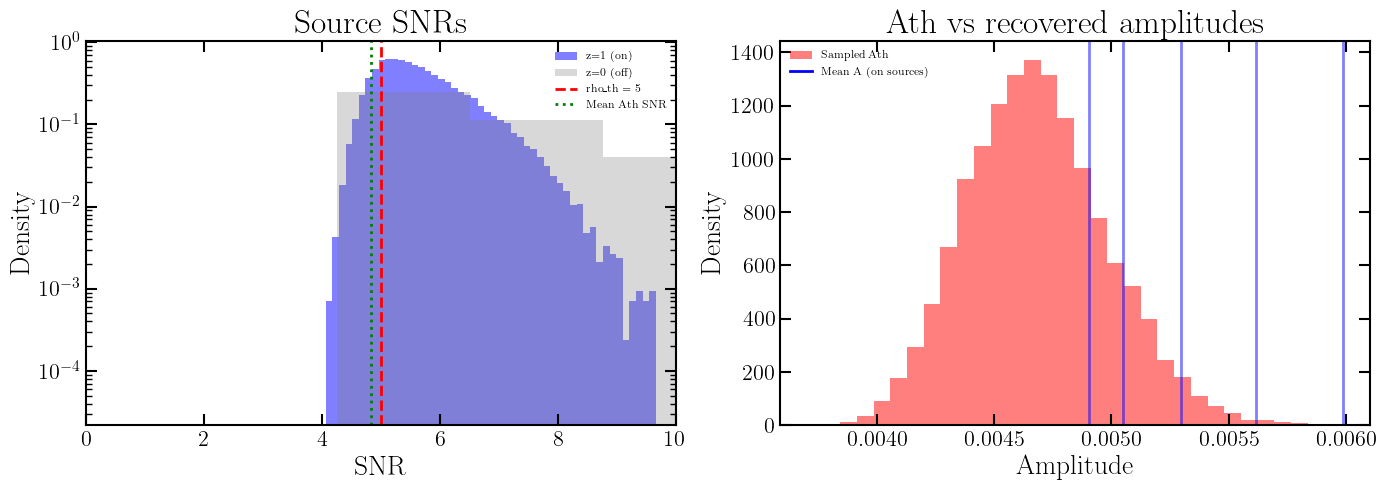

Mean Ath: 0.0047
Mean sconf: 8.29
SNR at Ath: 4.8
Median SNR (on): 5.5
Fraction on with SNR < rho_th: 0.17


In [46]:
# Investigate SNRs and A compared to Ath for on sources. 
# The sources are really close to threshold. But are always there, seemingly. 
# What's interesting, is that they pick up the right frequency, but not the correct amlitude. 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compute SNR for each source at each sample
# SNR = 2 * A * sqrt(Tobs) / sqrt(psd_level + sconf)
snrs_all = (2 * samples['amplitudes'] * jnp.sqrt(Tobs) 
            / jnp.sqrt(psd_level + samples['sconf'][:, None]))

# Left: histogram of SNRs for "on" sources only
snrs_on = snrs_all[samples['z'] == 1].ravel()
snrs_off = snrs_all[samples['z'] == 0].ravel()

axes[0].hist(snrs_on, bins=50, density=True, alpha=0.5, color='blue', label='z=1 (on)')
axes[0].hist(snrs_off, bins=50, density=True, alpha=0.3, color='grey', label='z=0 (off)')
axes[0].axvline(rho_th, color='red', ls='--', label=f'rho_th = {rho_th}')
axes[0].axvline(float(samples['Ath'].mean()) * 2 * jnp.sqrt(Tobs / (psd_level + samples['sconf'].mean())),
                color='green', ls=':', label='Mean Ath SNR')
axes[0].set_xlabel('SNR')
axes[0].set_ylabel('Density')
axes[0].set_title('Source SNRs')
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, 10)
axes[0].set_yscale('log')

# Right: scatter of sampled Ath vs amplitude for on sources
axes[1].hist(samples['Ath'], bins=30, density=True, alpha=0.5, color='red', label='Sampled Ath')
for k in range(samples['amplitudes'].shape[1]):
    on_mask = samples['z'][:, k] == 1
    if jnp.sum(on_mask) > 10:
        axes[1].axvline(jnp.mean(samples['amplitudes'][on_mask, k]), 
                        color='blue', alpha=0.5, ls='-')
axes[1].plot([], [], color='blue', label='Mean A (on sources)')
axes[1].set_xlabel('Amplitude')
axes[1].set_ylabel('Density')
axes[1].set_title('Ath vs recovered amplitudes')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("plots/snr_diagnostics.pdf")
plt.show()

# Print summary
print(f"Mean Ath: {np.mean(samples['Ath']):.4f}")
print(f"Mean sconf: {np.mean(samples['sconf']):.2f}")
print(f"SNR at Ath: {2 * np.mean(samples['Ath']) * np.sqrt(Tobs / (psd_level + np.mean(samples['sconf']))):.1f}")
print(f"Median SNR (on): {np.median(snrs_on):.1f}")
print(f"Fraction on with SNR < rho_th: {np.mean(snrs_on < rho_th):.2f}")

In [47]:
# What's the actual likelihood gain from turning each source on?
z_mean = np.mean(samples['z'], axis=0)
print("P(on) per slot:", np.round(np.sort(z_mean)[::-1], 2))

# How many are persistently on?
print("Slots with P(on) > 0.8:", np.sum(z_mean > 0.8))
print("Slots with P(on) > 0.5:", np.sum(z_mean > 0.5))
print("Mean sum(z):", np.mean(np.sum(samples['z'], axis=1)))

P(on) per slot: [1.   1.   1.   0.68 0.08]
Slots with P(on) > 0.8: 3
Slots with P(on) > 0.5: 4
Mean sum(z): 3.7524


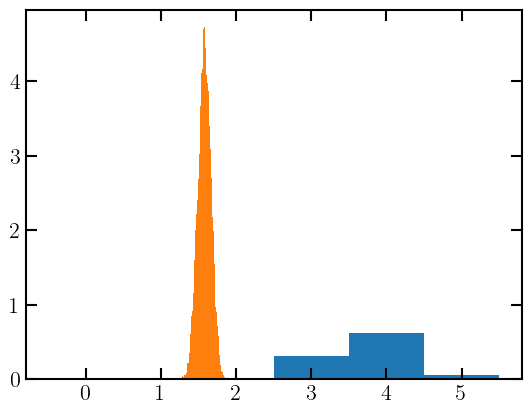

In [59]:
plt.hist(np.sum(samples['z'], axis=1), np.linspace(-0.5, max_num_resolvable + 0.5, max_num_resolvable+2), density=True)
plt.hist(samples['Nres'], bins='auto', density=True)
# plt.yscale("log")
plt.show()

In [49]:
h_test = tophat_fd_waveform(A_lower, 1.5e-4, 0.0, fdot, frequencies)
n_nonzero = jnp.sum(jnp.abs(h_test) > 0)
h_power_per_bin = jnp.sum(jnp.abs(h_test)**2) / n_nonzero

print(f"Waveform power per bin for A={A_lower}: {h_power_per_bin:.4e}")
print(f"Expected A^2 * Tobs / w: {A_lower**2 * Tobs / w:.4e}")
print(f"Ratio: {h_power_per_bin / (A_lower**2 * Tobs / w):.4f}")

# What total power does the formula predict?
print(f"\nmu (sources per bin): {mu:.1f}")
print(f"Formula Sconf: {Sconf_init:.4f}")
print(f"Empirical Sconf: {2 * jnp.mean(jnp.abs(fake_signals)**2) / Tobs:.4f}")

Waveform power per bin for A=0.001: 3.3592e+05
Expected A^2 * Tobs / w: 3.3592e+05
Ratio: 1.0000

mu (sources per bin): 15.4
Formula Sconf: 9.6847
Empirical Sconf: 10.3440


<>:44: SyntaxWarning: invalid escape sequence '\#'
<>:44: SyntaxWarning: invalid escape sequence '\#'
/var/folders/6y/tmhw8hp56_3888btjkrlhh6r0000gn/T/ipykernel_67257/3028850417.py:44: SyntaxWarning: invalid escape sequence '\#'
  label=f'Injected \#{rank+1}: A={Amplitudes[i]:.4f}, SNR={2*Amplitudes[i]*jnp.sqrt(Tobs/(psd_level + Sconf_init)):.1f}')


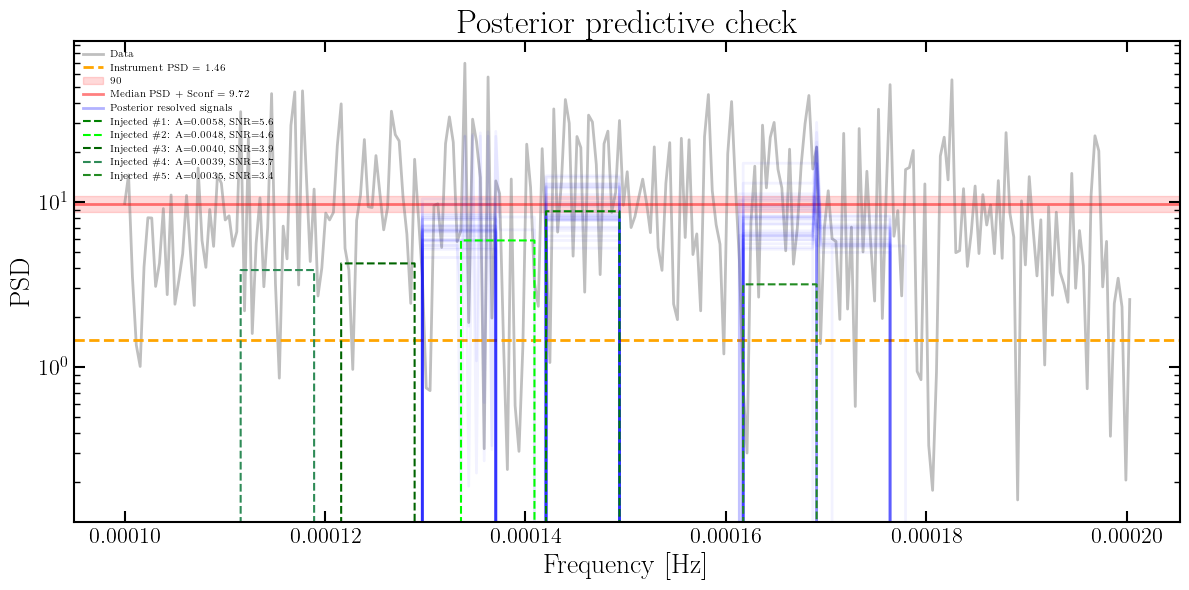

In [50]:
# Find top 5 by amplitude
top5_idx = np.argsort(Amplitudes)[::-1][:5]

fig, ax = plt.subplots(figsize=(12, 6))

# Data
data_psd = 2 * jnp.abs(fake_data_total)**2 / Tobs
ax.plot(frequencies, data_psd, color='grey', alpha=0.5, label='Data')

# Detector noise level
ax.axhline(psd_level, color='orange', ls='--', label=f'Instrument PSD = {psd_level:.2f}')

# Sconf band
sconf_samples = samples['sconf']
psd_total_lo, psd_total_mid, psd_total_hi = np.percentile(
    psd_level + sconf_samples, [5, 50, 95])
ax.axhspan(psd_total_lo, psd_total_hi, color='red', alpha=0.15, label='90% CI: PSD + Sconf')
ax.axhline(psd_total_mid, color='red', ls='-', alpha=0.5,
           label=f'Median PSD + Sconf = {psd_total_mid:.2f}')

# Posterior resolved waveforms
n_plot = min(100, samples['amplitudes'].shape[0])
idxs = np.random.choice(samples['amplitudes'].shape[0], n_plot, replace=False)
for idx in idxs[:30]:
    A_s = samples['amplitudes'][idx]
    f_s = samples['freq_centers'][idx]
    phi_s = samples['phi_centers'][idx]
    z_s = samples['z'][idx]
    if jnp.sum(z_s) == 0:
        continue
    h_pred = jnp.sum(
        z_s[:, None] * jax.vmap(
            lambda a, fc, phi: tophat_fd_waveform(a, fc, phi, fdot, frequencies)
        )(A_s, f_s, phi_s), axis=0)
    ax.plot(frequencies, 2 * jnp.abs(h_pred)**2 / Tobs, color='blue', alpha=0.05)
ax.plot([], [], color='blue', alpha=0.3, label='Posterior resolved signals')

# Top 5 injected waveforms individually
colors = ['green', 'lime', 'darkgreen', 'seagreen', 'forestgreen']
for rank, i in enumerate(top5_idx):
    h_i = tophat_fd_waveform(Amplitudes[i], fcenters[i], phi_centers[i],
                              fdot, frequencies)
    ax.plot(frequencies, 2 * jnp.abs(h_i)**2 / Tobs, color=colors[rank], ls='--', lw=1.5,
            label=f'Injected \#{rank+1}: A={Amplitudes[i]:.4f}, SNR={2*Amplitudes[i]*jnp.sqrt(Tobs/(psd_level + Sconf_init)):.1f}')

ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("PSD")
ax.set_yscale("log")
ax.legend(loc='upper left', fontsize=7)
ax.set_title("Posterior predictive check")
plt.tight_layout()
plt.savefig("plots/posterior_predictive.pdf")
plt.show()

In [51]:
n_mc = 50
sconf_mc = []
for _ in range(n_mc):
    A_draw = priors.sample_power_law_bounded(alpha, A_lower, 10.0, N_sources)
    fc_draw = np.random.uniform(flow, fhigh, N_sources)
    phi_draw = np.random.uniform(0, 2 * np.pi, N_sources)
    h_total = jnp.sum(jax.vmap(
        lambda a, fc, phi: tophat_fd_waveform(a, fc, phi, fdot, frequencies)
    )(A_draw, fc_draw, phi_draw), axis=0)
    sconf_mc.append(float(2 * jnp.mean(jnp.abs(h_total)**2) / Tobs))

print(f"MC Sconf: {np.mean(sconf_mc):.4f} ± {np.std(sconf_mc):.4f}")
print(f"Analytic Sconf: {float(Sconf_init):.4f}")
print(f"Ratio: {np.mean(sconf_mc) / float(Sconf_init):.2f}")

MC Sconf: 11.2102 ± 1.8812
Analytic Sconf: 9.6847
Ratio: 1.16


# Fast Gibbs

In [ ]:
# def numpyro_model2(data, max_num_resolvable=20, fdot=fdot, A_lower=A_lower,
#                   frequencies=frequencies):
#     log_10_N_sources = numpyro.sample("log_10_N_sources", dist.Uniform(1, 4))
#     log10_psd_val = numpyro.sample('log10_psd', dist.Uniform(-1, 2))
#     alpha = numpyro.sample("alpha", dist.Uniform(2.0, 6.0))

#     Ath, Sconf_mean, var_Sconf_ff = get_threshold_and_conf_noise_for_powerlaw(
#         Tobs, fhigh - flow, psd_level, 10**log_10_N_sources, alpha, rho_th, A_lower, 0,
#         phase_variance=True, N_variance=False)

#     sconf_sigma = numpyro.sample('sconf_sigma', dist.Uniform(0.01, 3.0))
#     sconf_raw = numpyro.sample("sconf_raw", dist.Normal(0, 1))
#     log_sconf = jnp.log(Sconf_mean) - sconf_sigma**2 / 2 + sconf_sigma * sconf_raw
#     sconf = numpyro.deterministic("sconf", jnp.exp(log_sconf))

#     u_amp = numpyro.sample("u_amp", dist.Uniform(0, 1).expand([max_num_resolvable]))
#     Ath_1ma = Ath**(1 - alpha)
#     hi_1ma = jnp.array(100.0)**(1 - alpha)
#     amplitudes = numpyro.deterministic("amplitudes",
#         (Ath_1ma + u_amp * (hi_1ma - Ath_1ma))**(1 / (1 - alpha)))

#     freq_centers = numpyro.sample("freq_centers",
#         dist.Uniform(flow, fhigh).expand([max_num_resolvable]))
#     phi_centers = numpyro.sample("phi_centers",
#         dist.Uniform(0, 2 * jnp.pi).expand([max_num_resolvable]))

#     z = numpyro.sample("z", dist.Bernoulli(0.5 * jnp.ones(max_num_resolvable)))

#     N_res = 10**log_10_N_sources * (A_lower / Ath)**(alpha - 1)
#     numpyro.factor("n_sources_prior", dist.Poisson(N_res).log_prob(jnp.sum(z)))
#     numpyro.deterministic("N_res", N_res)
#     # Compute waveforms and matched filter coefficients
#     psd_total = 10**log10_psd_val + sconf
#     waveforms = jax.vmap(
#         lambda a, fc, phi, fd: tophat_fd_waveform(a, fc, phi, fd, frequencies)
#     )(amplitudes, freq_centers, phi_centers, fdot * jnp.ones(max_num_resolvable))

#     dd, hd, hh = mf.filter_coefficients(waveforms, data, psd_total, frequencies)

#     # Store for Gibbs step
#     numpyro.deterministic("dd", dd)
#     numpyro.deterministic("hd", hd)
#     numpyro.deterministic("hh", hh)

#     # Likelihood as quadratic form in z
#     ll = -0.5 * (dd - 2 * jnp.dot(z, hd) + jnp.dot(z, hh @ z))
#     numpyro.deterministic("likelihood", ll)
#     numpyro.factor('ll', ll)

In [ ]:
def gibbs_fn(rng_key, gibbs_sites, hmc_sites):
    z = gibbs_sites['z']
    dd = hmc_sites['dd']
    hd = hmc_sites['hd']
    hh = hmc_sites['hh']

    # Poisson prior pieces (need these from hmc_sites too)
    N_res = hmc_sites['N_res']  # you'll need to store this as a deterministic

    n_sources = max_num_resolvable

    def scan_body(z, k):
        # Log-likelihood with z_k = 1
        z_on = z.at[k].set(1.0)
        ll_on = -0.5 * (dd - 2 * jnp.dot(z_on, hd) + jnp.dot(z_on, hh @ z_on))

        # Log-likelihood with z_k = 0
        z_off = z.at[k].set(0.0)
        ll_off = -0.5 * (dd - 2 * jnp.dot(z_off, hd) + jnp.dot(z_off, hh @ z_off))

        # Poisson prior on count
        n_on = jnp.sum(z_on)
        n_off = jnp.sum(z_off)
        prior_on = dist.Poisson(N_res).log_prob(n_on)
        prior_off = dist.Poisson(N_res).log_prob(n_off)

        log_odds = (ll_on + prior_on) - (ll_off + prior_off)
        p_on = jax.nn.sigmoid(log_odds)

        rng_key_k = jax.random.fold_in(rng_key, k)
        z_k_new = jax.random.bernoulli(rng_key_k, p_on).astype(float)
        z = z.at[k].set(z_k_new)
        return z, None

    z, _ = jax.lax.scan(scan_body, z, jnp.arange(n_sources))
    gibbs_sites['z'] = z
    return gibbs_sites

In [ ]:
# from numpyro.infer.util import initialize_model
# from numpyro.infer import init_to_value



# max_num_resolvable = 20
# n_true = int(np.sum(resolvable_sources_mask))

# # Pad true values into first n_true slots, fill remainder with draws from prior
# Ath_init, Sconf_init, _ = get_threshold_and_conf_noise_for_powerlaw(
#     Tobs, fhigh - flow, psd_level, N_sources, alpha, rho_th, A_lower, 0,
#     phase_variance=True, N_variance=False)

# init_amplitudes = jnp.concatenate([
#     A_inj_resolvable,
#     priors.sample_power_law_bounded(alpha, Ath_init, 10, max_num_resolvable - n_true)
# ])
# init_freq_centers = jnp.concatenate([
#     fcenters_resolvable,
#     np.random.uniform(flow, fhigh, max_num_resolvable - n_true)
# ])
# init_phi_centers = jnp.concatenate([
#     phi_centers_resolvable,
#     np.random.uniform(0, 2 * np.pi, max_num_resolvable - n_true)
# ])
# init_z = jnp.concatenate([jnp.ones(n_true), jnp.zeros(max_num_resolvable - n_true)])

# init_values = {
#     "log_10_N_sources": jnp.log10(jnp.array(N_sources, dtype=float)),
#     "alpha": jnp.array(3.99),
#     "log10_psd": jnp.log10(jnp.array(psd_level, dtype=float)),
#     "sconf_sigma": jnp.array(0.5),
#     "log_sconf": jnp.log(Sconf_init),
#     "amplitudes": init_amplitudes,
#     "freq_centers": init_freq_centers,
#     "phi_centers": init_phi_centers,
#     "z": init_z,
# }
# kernel2 = infer.HMCGibbs(
#     infer.NUTS(numpyro_model2, init_strategy=init_to_value(values=init_values),
#                target_accept_prob=0.9),
#     gibbs_fn=gibbs_fn,
#     gibbs_sites=["z"])
# # kernel = infer.DiscreteHMCGibbs(
# #     infer.NUTS(numpyro_model, init_strategy=init_to_value(values=init_values), max_tree_depth=8),
# #     modified=True)
# mcmc2 = infer.MCMC(kernel2, num_warmup=1000, num_samples=1000, num_chains=1)
# mcmc2.run(jax.random.key(0), fake_data_total)

